## Dependencies

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import xgboost as xgb
from tqdm import tqdm
import pandas as pd
import numpy as np 
import torch
import joblib

## Synthetic datasets generation

### Donors dataset

In [ ]:
# Calculates Total Blood Volume (TBV) in Liters using the Nadler Formula.
def calculate_nadler_bv(sex: str, height_cm: float, weight_kg: float):
    h_m = height_cm / 100
    if sex == 'M':
        # Male formula
        bv = (0.3669 * (h_m**3)) + (0.03219 * weight_kg) + 0.6041
    else:
        # Female formula
        bv = (0.3561 * (h_m**3)) + (0.03308 * weight_kg) + 0.1833
    return bv

# Simulates a Terumo Trima Accel donation, enforcing a 90-minute maximum and downgrading yields accordingly.
def predict_platelet_yield(weight_kg: float, 
                            ebv: float, 
                            platelet_count_k_per_ul: int):
    # Simulation Constants
    TARGET_YIELDS_E11 = [8.2, 7.8, 5.8, 5.4, 5.1, 3.0] # Triple -> Double -> Single
    
    CITRATE_INFUSION_LIMIT = 1.25
    AC_RATIO = 11.0           
    CITRATE_CONC_MG_ML = 15.4  
    COLLECTION_EFFICIENCY = 0.60
    
    # Time constraint
    MAX_DONATION_TIME_MIN = 90.0   
    MIN_POST_PLATELET_COUNT = 100000 
    # Calculate EBV in ml
    tbv_ml = ebv * 1000

    # Calculate Citrate-Driven Flow Rates
    max_ac_rate_ml_min = (CITRATE_INFUSION_LIMIT * weight_kg) / CITRATE_CONC_MG_ML
    max_inlet_flow_ml_min = max_ac_rate_ml_min * AC_RATIO
    inlet_flow_ml_min = min(max_inlet_flow_ml_min, 100.0)

    # Determine Yield Potential (Biological/Safety Limits)
    platelet_count_per_ml = platelet_count_k_per_ul * 1000.0 * 1000.0
    # Rate of collection: Platelets per minute
    platelets_per_min = platelets_collected_per_ml_processed = (platelet_count_per_ml * COLLECTION_EFFICIENCY * inlet_flow_ml_min)
    
    # Constraint: Min Post-Count (Donor Safety)
    max_safe_take = (tbv_ml * platelet_count_per_ml) - (MIN_POST_PLATELET_COUNT * 1000 * tbv_ml)
    max_yield_post = max_safe_take / 1e11

    # Find Target and Enforce Time Limit
    selected_yield = 0
    predicted_time_min = 0
    status = "Donor deferred: Procedure exceeds 90 mins even for single dose."

    # Iterate through target yields from highest to lowest
    for target in TARGET_YIELDS_E11:
        # Calculate time required for each specific target
        time_required = (target * 1e11) / platelets_per_min
        
        # Check if donor has enough platelets and if it fits in 90 mins
        if (max_yield_post >= target) and (time_required <= MAX_DONATION_TIME_MIN):
            selected_yield = target
            predicted_time_min = time_required
            status = f"Target {target}e11 achieved within {round(predicted_time_min, 1)} mins."
            break
    else:
        # Fallback logic if no standard target is met within 90 mins
        # Calculate what they can give in exactly 90 mins
        max_yield_in_90 = (MAX_DONATION_TIME_MIN * platelets_per_min) / 1e11
        selected_yield = min(max_yield_in_90, max_yield_post)
        predicted_time_min = (selected_yield * 1e11) / platelets_per_min

    return [
        round(selected_yield, 2),
        round(predicted_time_min, 1),
        round(inlet_flow_ml_min, 2),
        round(tbv_ml, 0),
        status
    ]

# Generates synthetic UK donor data ensuring: 93% Male donor distribution, minimum Blood Volume of 3.8L, 
# platelet count between 150 and 450 (x10^9/L).
def machine_setup():
    # Initialise eligibility flag
    eligible = False
    # Continuous loop until we generate an eligible donor profile
    while not eligible:
        # Apply the 93% Male donor skew
        sex = np.random.choice(['M', 'F'], p=[0.93, 0.07])
        
        # Generate Biometrics from UK mean/SD (2020-2025 data)
        if sex == 'M':
            height = np.random.normal(177, 7.1)
            weight = np.random.normal(85.1, 15.8)
            platelets = np.random.normal(235, 55)
            hematocrit = np.random.randint(40, 55)
        else:
            height = np.random.normal(164.6, 6.5)
            weight = np.random.normal(71.8, 16.2)
            platelets = np.random.normal(258, 62)
            hematocrit = np.random.randint(36, 49)
            
        # Validation Logic
        donor_bv = calculate_nadler_bv(sex, height, weight)
        
        # Check all three clinical constraints
        if (donor_bv >= 3.8) and (150 <= platelets <= 450):
            eligible = True

    # Final Donor Profile
    age = np.random.randint(18, 76)
    donations = np.random.randint(0, 51) if age > 20 else np.random.randint(0, 10)

    data = {
        'Donor age': int(age),
        'Donor sex': sex,
        'Height': round(height, 1),
        'Weight': round(weight, 1),
        'Hematocrits': round(hematocrit, 1),
        'Platelets count': int(platelets),
        'Donation number': donations,
        'Blood Volume (L)': round(donor_bv, 2)
    }

    inserted_data = list(data.values())

    # Calculate predicted yield
    predicted_donation_values = predict_platelet_yield(
        weight_kg=data['Weight'],
        ebv=donor_bv,
        platelet_count_k_per_ul=data['Platelets count']
    )

    return inserted_data, predicted_donation_values


In [ ]:
# Initialize empty dictionary to store synthetic donor data
dict_data = {
    'Donor ID': [],
    'Donor age': [],
    'Donor sex': [],
    'Height': [],
    'Weight': [],
    'Hematocrits': [],
    'Platelets count': [],
    'Donation number': [],
    'Blood Volume': [],
    'Yield': [],
    'Time': []
}

# Populate the dictionary with synthetic data for 100,000 donors
for id in range(100000):
    donor_data, donation_data = machine_setup()
    for idx, key in enumerate(dict_data):
        if idx == 0:
            dict_data[key].append(id)
        else:
            if idx < (len(donor_data)+1):
                dict_data[key].append(donor_data[idx-1])
            else:
                dict_data[key].append(donation_data[idx-len(donor_data)-1])

# Convert the dictionary to a DataFrame for analysis
pd_donors_db = pd.DataFrame.from_dict(dict_data)

# Optional: Save to CSV for future use
# pd_donors_db.to_csv('synthetic_donors_data.csv', index=False)

# Display the first few rows of the DataFrame
pd_donors_db.head()

,Donor ID,Donor age,Donor sex,Height,Weight,Hematocrits,Platelets count,Donation number,Blood Volume,Yield,Time
0,0,20,M,170.0,81.7,53,346,5,5.04,8.2,54.1
1,1,20,M,170.5,79.0,54,315,6,4.97,8.2,61.5
2,2,60,M,183.0,100.7,41,217,8,6.09,5.8,49.5
3,3,65,F,166.2,72.4,45,295,23,4.21,8.2,71.7
4,4,44,M,177.2,110.4,53,226,10,6.20,7.8,58.4


### Donations dataset

In [14]:
# Sets the donation parameters at the beginning of the donation based on the donor data, 
# and adds the necessary parameters for the simulation to run (e.g. EBV risk bracket, yield dose)
def parameters_starter(donor_data: pd.Series, params: dict):
    # Lookm up donation yield and assign yield dose parameter based on the donor data
    donation_yield = float(donor_data['Yield'])
    # Find yield dose
    if donation_yield < 5:
        params['yield'] = 0
    elif 5 < donation_yield < 7:
        params['yield'] = 1
    else:
        params['yield'] = 2
    # Find EBV risk bracket
    donor_EBV = float(donor_data['Blood Volume'])
    if 3.8 <= donor_EBV < 4.3:
        params['donorEBVRiskBracket'] = 0
    elif 4.3 <= donor_EBV < 4.8:
        params['donorEBVRiskBracket'] = 1
    else:
        params['donorEBVRiskBracket'] = 2

    # Update static donor parameters
    params['donorID'] = int(donor_data['Donor ID'])
    params['donorAge'] = int(donor_data['Donor age'])
    params['totalDonations'] = int(donor_data['Donation number'])
    params['donorSex'] = donor_data['Donor sex']
    params['lowerPlateletsCount'] = int(donor_data['Platelets count'])
    params['donationTime'] = int(donor_data['Time'])
    if donor_data['Donation number'] <= 16:
        # Give a chance of having AC reaction history 
        params['donorHasACReactionHistory'] = np.random.choice(['yes', 'no'])
    if donor_data['Donation number'] < 16:
        # Give a chance of having high return history
        params['donorHasHighReturnHistory'] = np.random.choice(['yes', 'no'])
    return params


# Set the chances for draw, return, and AC flow to be abnormal depending on the adjustments made during the donation
def scenario_orchestrator(params: dict, 
                          bias: bool, 
                          AC_bias: bool, 
                          return_flow_reduced: int, 
                          AC_concentration_reduced: bool, 
                          machine_paused_for_AC: bool) :
    # Initaiate output list with normal flow values
    output = ['normal_draw', 'normal_return', 'normal_AC']
    # Calculate chances
    # DRAW FLOW
    # Bias scenario
    if bias:
        # 60% chance of being low draw when no needle adjustment is performed
        if params['needleAdjusted'] == 0:
            low_draw = True if np.random.randint(5) in [0, 1, 2] else False
        # 40% chance of being low draw when needle adjustment is performed
        elif params['needleAdjusted'] == 1:
            low_draw = True if np.random.randint(5) in [0, 1] else False
        # 25% chance of being low draw when 2 needle adjustments are performed
        else:
            low_draw = True if np.random.randint(4) == 0 else False
    # NO bias scenario
    else:
        # 33% chance of being low draw if no needle adjustment is performed
        if params['needleAdjusted'] == 0:
            low_draw = True if np.random.randint(3) == 0 else False
        # 20% chance of being low draw when needle adjustment is performed
        elif params['needleAdjusted'] == 1:
            low_draw = True if np.random.randint(5) == 0 else False
        # 10% chance of being low draw if needle adjustment is performed
        else:
            low_draw = True if np.random.randint(10) == 0 else False

    # RETURN FLOW
    # Determine baseline risk using the "reduce return speed" label rules
    total_donations = params['totalDonations']
    operator = params['operator']
    vein_used = params['veinUsed']
    history = params['donorHasHighReturnHistory']
    instances = params['highReturnInstances']

    is_high_risk = False
    
    # Flag high risk based on the label rules 
    if total_donations >= 70:
        is_high_risk = True
    elif 15 < total_donations < 70 and (operator == 'junior' and vein_used == 'Basilic'):
        is_high_risk = True
    elif total_donations < 16 and (history == 'yes' or operator == 'junior' or vein_used == 'Basilic'):
        is_high_risk = True
    elif total_donations >= 70 and (operator == 'junior' or vein_used == 'Basilic'):
        is_high_risk = True

    # Apply probabilities based on mitigation status (return_flow_reduced)
    if is_high_risk:
        # 33% starting chance of being high return if risk factors are present
        high_return = True if np.random.randint(3 + return_flow_reduced) == 0 else False
    else:
        # 16.6% starting chance of being high return
        high_return = True if np.random.randint(6 + return_flow_reduced) == 0 else False

    # AC FLOW
    # Bias scenario
    if AC_bias:
        # High EBV risk donors chances
        if params['donorEBVRiskBracket'] == 0:
            if AC_concentration_reduced and machine_paused_for_AC:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            elif AC_concentration_reduced:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
            elif machine_paused_for_AC:
                # 50% chance of being high AC
                high_AC = True if np.random.randint(2) == 0 else False
            else:
                # 60% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1, 2] else False
        # Medium EBV risk donors chances
        elif params['donorEBVRiskBracket'] == 1:
            if AC_concentration_reduced and machine_paused_for_AC:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
            elif AC_concentration_reduced:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            elif machine_paused_for_AC:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
            else:
                # 50% chance of being high AC
                high_AC = True if np.random.randint(2) == 0 else False
        # Low EBV risk donors chances
        elif params['donorEBVRiskBracket'] == 2:
            if AC_concentration_reduced and machine_paused_for_AC:
                # 10% chance of being high AC
                high_AC = True if np.random.randint(10) == 0 else False
            elif AC_concentration_reduced:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
            elif machine_paused_for_AC:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            else:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
    else:
        # High EBV risk donors chances
        if params['donorEBVRiskBracket'] == 0:
            if AC_concentration_reduced and machine_paused_for_AC:
                # 10% chance of being high AC
                high_AC = True if np.random.randint(10) == 0 else False
            elif AC_concentration_reduced:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
            elif machine_paused_for_AC:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            else:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
        # Medium and Low EBV risk donors chances
        else:
            if AC_concentration_reduced and machine_paused_for_AC:
                # 4.5% chance of being high AC
                high_AC = True if np.random.randint(22) == 0 else False
            elif AC_concentration_reduced:
                # 10% chance of being high AC
                high_AC = True if np.random.randint(10) == 0 else False
            elif machine_paused_for_AC:
                # 16.6% chance of being high AC
                high_AC = True if np.random.randint(6) == 0 else False
            else:
                # 25% chance of being high AC
                high_AC = True if np.random.randint(4) == 0 else False
    # Assign output
    if low_draw:
        output[0] = 'low_draw'
    if high_return:
        output[1] = 'high_return'
    if high_AC:
        output[-1] = 'high_AC'
    return output


# Machine low draw flow stop logic
def low_draw_stop_logic(params: dict):
    # Only stop machine in case of 3 red squares in a row
    if params['prev_variance'] == 0 and params['prev_variance_1'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0:
        params['instancesMachineStopped'] += 1
        # Extend donation due to low draw speed
        params['donationTime'] += 10
        return params
    else: return params


# Speed up donation time if the last 5 draw cycles were good, and the donation time is currently longer than the original predictet time
def draw_speed_boost(params: dict, initial_donation_time: int):
    cycle_variance = params['machineRedSquaresVarianceInCicles']
    current_donation_time = params['donationTime']
    if cycle_variance > 4 and current_donation_time > initial_donation_time:
        if (current_donation_time - params['donationElapsedTime']) <= 11:
            pass
        else:
            params['donationTime'] -= 10
    return params


# Update previous red square variances
def prev_variance_updater(params: dict):
    params['prev_variance_1'] = params['prev_variance']
    params['prev_variance'] = params['machineRedSquaresVarianceInCicles']
    return params


# Action scenario orcehstrator output
def draw_flow(orchestrator_output: list, params: dict, original_time: int):
    # Check orchestrator output
    if 'low_draw' == orchestrator_output[0]:
        # Add probability of the machine stopping due to low draw, variance <= 2, machine paused >=3
        params = prev_variance_updater(params)
        params['machineRedSquaresVarianceInCicles'] = 0
        params = low_draw_stop_logic(params)
    else:
        params = prev_variance_updater(params)
        params['machineRedSquaresVarianceInCicles'] = int(params['machineRedSquaresVarianceInCicles']) + 1
        params = draw_speed_boost(params, original_time)
    return params


# Action scenario orcehstrator output
def return_flow(orchestrator_output: list, params: dict):
    end_donation = False
    # Check orchestrator output
    if 'high_return' in orchestrator_output:
        # 7% chance that the return bruises the donor
        if (np.random.randint(14) == 0):
            params['timePressureBarGoingToYellowInSeconds'] = np.random.randint(6, 11)
            params['highReturnInstances'] += 1
            end_donation = True
            return params, end_donation
        # 50% chance of being a slightly high return flow
        if (np.random.randint(2) == 0):
            params['timePressureBarGoingToYellowInSeconds'] = np.random.randint(3, 6)
        else:
            params['timePressureBarGoingToYellowInSeconds'] = np.random.randint(6, 11)
            params['highReturnInstances'] += 1
    # If not high return, reset the seconds count
    else:
        params['timePressureBarGoingToYellowInSeconds'] = 0
    return params, end_donation


# Action scenario orcehstrator output
def AC_flow(orchestrator_output: list, params: dict):
    # Check for previous cycle reaction
    if params['reactionSeverity'] != 0:
        # Update previous reaction parameter
        params['prevACReaction'] = params['reactionSeverity']
    # Reset reaction for current cycle
    params['reactionSeverity'] = 0
    # Check orchestrator output
    if 'high_AC' in orchestrator_output:
        # 33% chance of AC reaction symptoms
        if (np.random.randint(3) == 0):
            params['reactionSeverity'] = int(np.random.choice([1, 2, 3], p=[0.7, 0.2, 0.1]))
            params['donorCurrentDonationReaction'] += 1
            params['instancesMachineWasStoppedByOperator'] += 1
    return params


# Assisgn label to each data row based on the priority rules, and the parameters of the donation at that moment.
def assign_label(params: dict) -> dict:
    detected_priorities = []
    # PRIORITY 1: Stop Donation
    if (params['reactionSeverity'] == 3 or
        (params['donorCurrentDonationReaction'] == 3) or
        # 1st reaction
            # High EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] > 0) or
        # 2nd reaction
            # High EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['yield'] == 0 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 1 and params['yield'] > 0 and params['reactionSeverity'] != 0) or
            # Medium EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['yield'] == 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 2 and params['yield'] == 2 and params['reactionSeverity'] != 0) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 2 and params['yield'] == 2 and params['reactionSeverity'] != 0)):
            detected_priorities.append((1, 'End donation, AC toxicity reached/buildup'))

    # PRIORITY 2: Reduce AC
        # 1st reaction
            # High EBV risk bracket
    if ((params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] == 0) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 1 and params['yield'] > 0) or
            # Medium EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 2 and params['yield'] == 2) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2 and params['yield'] == 2) or
        # 2nd reaction
            # High EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 1 and params['yield'] == 0 and params['reactionSeverity'] != 0) or
            # Medium EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['yield'] < 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 2 and params['yield'] < 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 1 and params['reactionSeverity'] != 0) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 2 and params['yield'] < 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] != 0 and params['reactionSeverity'] != 0)):
        detected_priorities.append((2, 'Inform nurse and lower AC concentration'))

    # PRIORITY 3: Pause Machine
        # 1st reaction
            # Medium EBV risk bracket
    if ((params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] < 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 2 and params['yield'] < 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 1) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2 and params['yield'] < 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] != 0)):
        detected_priorities.append((3, 'Pause machine for 1 minute and inform nurse'))

    # PRIORITY 4: Return Speed
    if ((params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['operator'] == 'junior' and 15 < params['totalDonations'] < 70) or
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['veinUsed'] == 'Basilic' and 15 < params['totalDonations'] < 70) or
        ## addition
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] >= 70) or # scarring from many donations
        ##
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['highReturnInstances'] % 2 == 0 and 15 < params['totalDonations'] < 70) or
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] < 16 and params['donorHasHighReturnHistory'] == 'yes') or 
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] < 16 and params['operator'] == 'junior') or 
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] < 16 and params['veinUsed'] == 'Basilic')):
        detected_priorities.append((4, 'Lower return speed from terminal'))

    # PRIORITY 5: Needle Adjustment 1
    if (params['needleAdjusted'] == 0 and \
        params['prev_variance'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0):
        detected_priorities.append((5, 'Request first needle adjustment'))

    # PRIORITY 6: Needle Adjustment 2
    if (params['needleAdjusted'] == 1 and \
        params['prev_variance'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0):
        detected_priorities.append((6, 'Request second needle adjustment'))

    # Final Decision: Sort by priority (lowest number first) and pick the top one
    if detected_priorities:
        detected_priorities.sort(key=lambda x: x[0])
        params['label'] = detected_priorities[0][1]
    else:
        params['label'] = 'No action'
    return params


# Dataset generator function, simulates the donation process minute by minute, 
# and applies the scenario orchestrator, flow logics, and label assignment at each step. 
# The output is a dataframe with the donation parameters at each minute, and the label for the action taken at that moment (if any). 
# It also outputs the final outcome of the donation (e.g. if it was stopped due to high return or AC reaction).
def running_sim(donor_data: pd.Series, outcomes: dict) -> pd.DataFrame:
    # Initiate parameters
    params = {
        'donorID': 0,
        'donorAge': 0,                                           
        'reactionSeverity': 0,                           
        'donorCurrentDonationReaction': 0,                                           
        'timePressureBarGoingToYellowInSeconds': 0,                                   
        'instancesMachineWasStoppedByOperator': 0,                                     
        'instancesMachineStopped': 0,  
        'lowerPlateletsCount': 0,                                                   
        'donationElapsedTime': 5,                                                 
        'donorSex': '',                                     
        'needleAdjusted': 0,                        
        'donorHasLowDrawHistory': 'no',                                         
        'donorHasHighReturnHistory': 'no',                 
        'donorEBVRiskBracket': 0,                              
        'prev_variance': 2,
        'prev_variance_1': 1,
        'machineRedSquaresVarianceInCicles': 3,                                      
        'donationTime': 0,
        'donorHasACReactionHistory': 'no',
        'prevACReaction': 0,
        'yield': 0,                                  
        'operator': '',
        'veinUsed': '',
        'highReturnInstances': 0,
        'totalDonations': 0,
        'label': 'No action',
    }
    # Update parameters to current donor
    params = parameters_starter(donor_data, params)
    # Assign random operator type
    params['operator'] = np.random.choice(['junior', 'senior'])
    # Assign random vein used
    params['veinUsed'] = np.random.choice(['Cephalic', 'Basilic', 'Median'], p=[0.2, 0.3, 0.5])
    # Extract donation time from list
    donation_time = int(donor_data['Time'])
    # Draw bias, 50% chance of biased draw
    bias = True if (np.random.randint(2) == 0) else False
    # AC bias, 50% chance of biased AC for female donor
    AC_bias = True if (np.random.randint(2) == 0) else False
    # FLAGS SETUP
    # Return flow reduced flag
    reduced_return = 0
    # AC reduction flag
    reduced_AC = False
    # Machine pause due to AC reaction flag
    machine_paused_for_AC = False
    # Extract donor ID
    donor_ID = int(donor_data['Donor ID'])
    # Initiate donation outcome
    outcome = 'No issues'
    # Initiate end donation status
    end_donation_status = False
    # Initial donation time
    initial_time = params['donationTime']
    # Loop through the minutes, and perform 1 return and 1 draw each minute
    for loop in range(donation_time - 5):
        scenario = scenario_orchestrator(params, bias, AC_bias, reduced_return, reduced_AC, machine_paused_for_AC)
        params = AC_flow(scenario, params)
        params = draw_flow(scenario, params, initial_time)
        params, end_donation_status = return_flow(scenario, params)
        params = assign_label(params)
        if end_donation_status:
            outcome = 'Donation stopped due to high return'
        if 'End donation,' in params['label']:
            end_donation_status = True
            outcome = 'Donation stopped due to AC reaction/buildup'
        if params['label'] == 'Lower return speed from terminal':
            reduced_return += 1
        if params['label'] == 'Inform nurse and lower AC concentration':
            reduced_AC = True
        if params['label'] == 'Pause machine for 1 minute and inform nurse':
            machine_paused_for_AC = True
        # Dataset setup
        if loop == 0:
            anchor = pd.DataFrame(params, index=[0])
        else:
            # Generate a new pandas series to add to the main dataframe
            new_entry = pd.DataFrame(params, index=[0])
            # Add overwritten params to the dataframe
            anchor = pd.concat([anchor, new_entry], axis=0)
            # Stop donation if it slows down to be longer than 94 minutes
            if params['donationTime'] > 94:
                end_donation_status = True
                outcome = 'Donation stopped due to timeout'
        # Check for needle adjustments
        if params['label'] == 'Request first needle adjustment' or \
        params['label'] == 'Request second needle adjustment':
            params['needleAdjusted'] += 1
        # Check early stop flag
        if end_donation_status:
            break
        params['donationElapsedTime'] += 1
    # If donation stopped early, return simulation results
    if end_donation_status:
        pass
    # If donation completed normally, check for time extension
    else:
        # Check for time dilation due to low draw
        new_donation_time = params['donationTime']
        # Set up stack for while loop
        extended_time_history = [new_donation_time]
        force_stop_donation = False
        original_time_history = [donation_time]
        if donation_time != new_donation_time:
            while original_time_history[-1] != extended_time_history[-1]:
                # Keep looping through the minutes, and perform 1 return and 1 draw each minute
                for loop in range(new_donation_time - donation_time):
                    # Ensure donation does not keep going after time update (speed boost)
                    if params['donationElapsedTime'] == params['donationTime']:
                        # Break for and while loop
                        force_stop_donation = True
                        break
                    scenario = scenario_orchestrator(params, bias, AC_bias, reduced_return, reduced_AC, machine_paused_for_AC)
                    params = AC_flow(scenario, params)
                    params = draw_flow(scenario, params, initial_time)
                    params, end_donation_status = return_flow(scenario, params)
                    params = assign_label(params)
                    if end_donation_status:
                        outcome = 'Donation stopped due to high return'
                    if 'End donation,' in params['label']:
                        end_donation_status = True
                        outcome = 'Donation stopped due to AC reaction/buildup'
                    if params['label'] == 'Lower return speed from terminal':
                        reduced_return += 1
                    if params['label'] == 'Inform nurse and lower AC concentration':
                        reduced_AC = True
                    if params['label'] == 'Pause machine for 1 minute and inform nurse':
                        machine_paused_for_AC = True
                    # Generate a new pandas series to add to the main dataframe
                    new_entry = pd.DataFrame(params, index=[0])
                    # Add overwritten params to the dataframe
                    anchor = pd.concat([anchor, new_entry], axis=0)
                    # Stop donation if it slows down to be longer than 94 minutes
                    if params['donationTime'] > 94:
                        end_donation_status = True
                        outcome = 'Donation stopped due to timeout'
                    # End donation early
                    if end_donation_status:
                        force_stop_donation = True
                        break
                    params['donationElapsedTime'] += 1
                if force_stop_donation:
                    break
                original_time_history.append(extended_time_history[-1])
                extended_time_history.append(params['donationTime'])
    outcomes['donor_ID'].append(donor_ID)
    outcomes['AC_bias'].append(AC_bias)
    outcomes['Draw_bias'].append(bias)
    outcomes['outcome'].append(outcome)
    return anchor, outcomes


# Engine to generate the synthetic dataset from the donors' data
def dataset_generator_engine(dataset_path: str = None, dataset: pd.DataFrame = None):
    # Read the source data
    if not dataset_path:
        entire_data = dataset
    else:
        entire_data = pd.read_csv(dataset_path)
    # Donation outcomes
    outcomes = {
        'donor_ID': [],
        'AC_bias': [],
        'Draw_bias': [],
        'outcome': []
    }
    # Loop through the dataset rows
    for idx in tqdm(range(len(entire_data)), desc=f"Generating dataset"):
        if idx == 0:
            seed_df, outcomes = running_sim(entire_data.loc[idx], outcomes)
        else:
            latest_entry, outcomes = running_sim(entire_data.loc[idx], outcomes)
            seed_df = pd.concat([seed_df, latest_entry], axis=0)
    pd_outcomes = pd.DataFrame(outcomes)
    return seed_df, pd_outcomes


# Function to inject noise into the dataset, simulating real-world data imperfections.
def inject_noise_gpu(df: pd.DataFrame, noise_level: float = 0.01) -> pd.DataFrame:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Injecting noise into {len(df):,} rows using {device}...")
    
    noisy_df = df.copy()
    n = len(noisy_df)
    
    # NOISE LAYER 1: Label Misclassification
    label_to_int = {
        'No action': 0, 
        'End donation, AC toxicity reached/buildup': 1, 
        'Inform nurse and lower AC concentration': 2,
        'Pause machine for 1 minute and inform nurse': 3, 
        'Lower return speed from terminal': 4,
        'Request first needle adjustment': 5, 
        'Request second needle adjustment': 6
    }
    int_to_label = {v: k for k, v in label_to_int.items()}
    
    # FIX: Use .values to ensure we get a clean array for Torch
    labels_tensor = torch.tensor(noisy_df['label'].map(label_to_int).values, device=device, dtype=torch.int)
    mislabel_mask = torch.rand(n, device=device) < (noise_level / 2.0)
    
    if mislabel_mask.any():
        num_mislabel = mislabel_mask.sum().item()
        labels_tensor[mislabel_mask] = torch.randint(0, 7, (num_mislabel,), device=device, dtype=torch.int)
    
    # FIX: Convert back to numpy, map, and assign via .values to avoid Index alignment issues
    noisy_df['label'] = pd.Series(labels_tensor.cpu().numpy()).map(int_to_label).values
    
    # NOISE LAYER 2: Sensor Jitter
    pressure = torch.tensor(noisy_df['timePressureBarGoingToYellowInSeconds'].values, device=device, dtype=torch.float)
    raw_noise = pressure + torch.randn(n, device=device) * (noise_level * 20)
    pressure_noise = torch.where(
        raw_noise > pressure, 
        torch.ceil(raw_noise), 
        torch.floor(raw_noise)
    ).clamp(0, 15)
    
    noisy_df['timePressureBarGoingToYellowInSeconds'] = pressure_noise.cpu().numpy().astype(int)
    
    # NOISE LAYER 3: Categorical Flip (Operator)
    op_to_int = {'junior': 0, 'senior': 1}
    int_to_op = {0: 'junior', 1: 'senior'}
    
    # FIX: Ensure .values is used here too
    op_tensor = torch.tensor(noisy_df['operator'].map(op_to_int).values, device=device, dtype=torch.int)
    op_flip_mask = torch.rand(n, device=device) < noise_level
    
    if op_flip_mask.any():
        op_tensor[op_flip_mask] = 1 - op_tensor[op_flip_mask]
        
    noisy_df['operator'] = pd.Series(op_tensor.cpu().numpy()).map(int_to_op).values
    
    # NOISE LAYER 4: EBV Variance
    ebv_tensor = torch.tensor(noisy_df['donorEBVRiskBracket'].values, device=device, dtype=torch.int)
    ebv_shift_mask = torch.rand(n, device=device) < (noise_level / 2.0)
    
    if ebv_shift_mask.any():
        num_shift = ebv_shift_mask.sum().item()
        shift = torch.randint(0, 2, (num_shift,), device=device, dtype=torch.int) * 2 - 1
        ebv_tensor[ebv_shift_mask] = (ebv_tensor[ebv_shift_mask] + shift).clamp(0, 2)
        
    noisy_df['donorEBVRiskBracket'] = ebv_tensor.cpu().numpy()

    return noisy_df

In [ ]:
dataset, outcomes = dataset_generator_engine(dataset=pd_donors_db)

Generating dataset: 100%|██████████| 100000/100000 [2:50:44<00:00,  9.76it/s] 


Injecting noise into 2,310,699 rows using cuda...


In [15]:
noisy_dataset = inject_noise_gpu(dataset, noise_level=0.01)

Injecting noise into 2,310,699 rows using cuda...


## EDA

In [36]:
# --- EBV RISK BRAKETS EXTRACTION ---
# Low risk (EBV >= 4.8)
low_risk_EBV_bracket = pd_donors_db.where(pd_donors_db['Blood Volume'] >= 4.8).dropna()
low_risk_EBV_bracket_female = int(low_risk_EBV_bracket['Donor ID'].where(low_risk_EBV_bracket['Donor sex'] == 'F').dropna().count())
low_risk_EBV_bracket_male = int(low_risk_EBV_bracket['Donor ID'].where(low_risk_EBV_bracket['Donor sex'] == 'M').dropna().count())
# Medium risk (4.3 <= EBV < 4.8)
x = pd_donors_db.where(pd_donors_db['Blood Volume'] >= 4.3).dropna()
medium_risk_EBV_bracket = x.where(x['Blood Volume'] < 4.8).dropna()
medium_risk_EBV_bracket_female = int(medium_risk_EBV_bracket['Donor ID'].where(medium_risk_EBV_bracket['Donor sex'] == 'F').dropna().count())
medium_risk_EBV_bracket_male = int(medium_risk_EBV_bracket['Donor ID'].where(medium_risk_EBV_bracket['Donor sex'] == 'M').dropna().count())
# High risk (EBV < 4.3)
high_risk_EBV_bracket = pd_donors_db.where(pd_donors_db['Blood Volume'] < 4.3).dropna()
high_risk_EBV_bracket_female = int(high_risk_EBV_bracket['Donor ID'].where(high_risk_EBV_bracket['Donor sex'] == 'F').dropna().count())
high_risk_EBV_bracket_male = int(high_risk_EBV_bracket['Donor ID'].where(high_risk_EBV_bracket['Donor sex'] == 'M').dropna().count())

# --- YIELD EXTRACTION ---
# Low risk 
lr_single_placeholder = pd_donors_db.where(pd_donors_db['Yield'] < 4).dropna()
lr_single = lr_single_placeholder.where(lr_single_placeholder['Blood Volume'] >= 4.8).dropna()
lr_single_female = int(lr_single['Yield'].where(lr_single['Donor sex'] == 'F').dropna().count())
lr_single_male = int(lr_single['Yield'].where(lr_single['Donor sex'] == 'M').dropna().count())

lr_double_placeholder_one = pd_donors_db.where(pd_donors_db['Yield'] > 5).dropna()
lr_double_placeholder_two = lr_double_placeholder_one.where(lr_double_placeholder_one['Yield'] < 6).dropna() 
lr_double = lr_double_placeholder_two.where(lr_double_placeholder_two['Blood Volume'] >= 4.8).dropna()
lr_double_female = int(lr_double['Yield'].where(lr_double['Donor sex'] == 'F').dropna().count())
lr_double_male = int(lr_double['Yield'].where(lr_double['Donor sex'] == 'M').dropna().count())

lr_triple_placeholder = pd_donors_db.where(pd_donors_db['Yield'] > 6).dropna()
lr_triple = lr_triple_placeholder.where(lr_triple_placeholder['Blood Volume'] >= 4.8).dropna()
lr_triple_female = int(lr_triple['Yield'].where(lr_triple['Donor sex'] == 'F').dropna().count())
lr_triple_male = int(lr_triple['Yield'].where(lr_triple['Donor sex'] == 'M').dropna().count())

# Medium risk
mr_single_placeholder_one = pd_donors_db.where(pd_donors_db['Yield'] < 4).dropna()
mr_single_placeholder_two = mr_single_placeholder_one.where(mr_single_placeholder_one['Blood Volume'] < 4.8).dropna()
mr_single = mr_single_placeholder_two.where(mr_single_placeholder_two['Blood Volume'] >= 4.3).dropna()
mr_single_female = int(mr_single['Yield'].where(mr_single['Donor sex'] == 'F').dropna().count())
mr_single_male = int(mr_single['Yield'].where(mr_single['Donor sex'] == 'M').dropna().count())

mr_double_placeholder_one = pd_donors_db.where(pd_donors_db['Yield'] > 5).dropna()
mr_double_placeholder_two = mr_double_placeholder_one.where(mr_double_placeholder_one['Yield'] < 6).dropna()
mr_double_placeholder_three = mr_double_placeholder_two.where(mr_double_placeholder_two['Blood Volume'] < 4.8).dropna()
mr_double = mr_double_placeholder_three.where(mr_double_placeholder_three['Blood Volume'] >= 4.3).dropna()
mr_double_female = int(mr_double['Yield'].where(mr_double['Donor sex'] == 'F').dropna().count())
mr_double_male = int(mr_double['Yield'].where(mr_double['Donor sex'] == 'M').dropna().count())

mr_triple_placeholder_one = pd_donors_db.where(pd_donors_db['Yield'] > 6).dropna()
mr_triple_placeholder_two = mr_triple_placeholder_one.where(mr_triple_placeholder_one['Blood Volume'] < 4.8).dropna()
mr_triple = mr_triple_placeholder_two.where(mr_triple_placeholder_two['Blood Volume'] >= 4.3).dropna()
mr_triple_female = int(mr_triple['Yield'].where(mr_triple['Donor sex'] == 'F').dropna().count())
mr_triple_male = int(mr_triple['Yield'].where(mr_triple['Donor sex'] == 'M').dropna().count())

# High risk
hr_single_placeholder = pd_donors_db.where(pd_donors_db['Yield'] < 4).dropna()
hr_single = hr_single_placeholder.where(hr_single_placeholder['Blood Volume'] < 4.3).dropna()
hr_single_female = int(hr_single['Yield'].where(hr_single['Donor sex'] == 'F').dropna().count())
hr_single_male = int(hr_single['Yield'].where(hr_single['Donor sex'] == 'M').dropna().count())

hr_double_placeholder_one = pd_donors_db.where(pd_donors_db['Yield'] > 5).dropna()
hr_double_placeholder_two = hr_double_placeholder_one.where(hr_double_placeholder_one['Yield'] < 6).dropna()
hr_double = hr_double_placeholder_two.where(hr_double_placeholder_two['Blood Volume'] < 4.3).dropna()
hr_double_female = int(hr_double['Yield'].where(hr_double['Donor sex'] == 'F').dropna().count())
hr_double_male = int(hr_double['Yield'].where(hr_double['Donor sex'] == 'M').dropna().count())

hr_triple_placeholder = pd_donors_db.where(pd_donors_db['Yield'] > 6).dropna()
hr_triple = hr_triple_placeholder.where(hr_triple_placeholder['Blood Volume'] < 4.3).dropna()
hr_triple_female = int(hr_triple['Yield'].where(hr_triple['Donor sex'] == 'F').dropna().count())
hr_triple_male = int(hr_triple['Yield'].where(hr_triple['Donor sex'] == 'M').dropna().count())


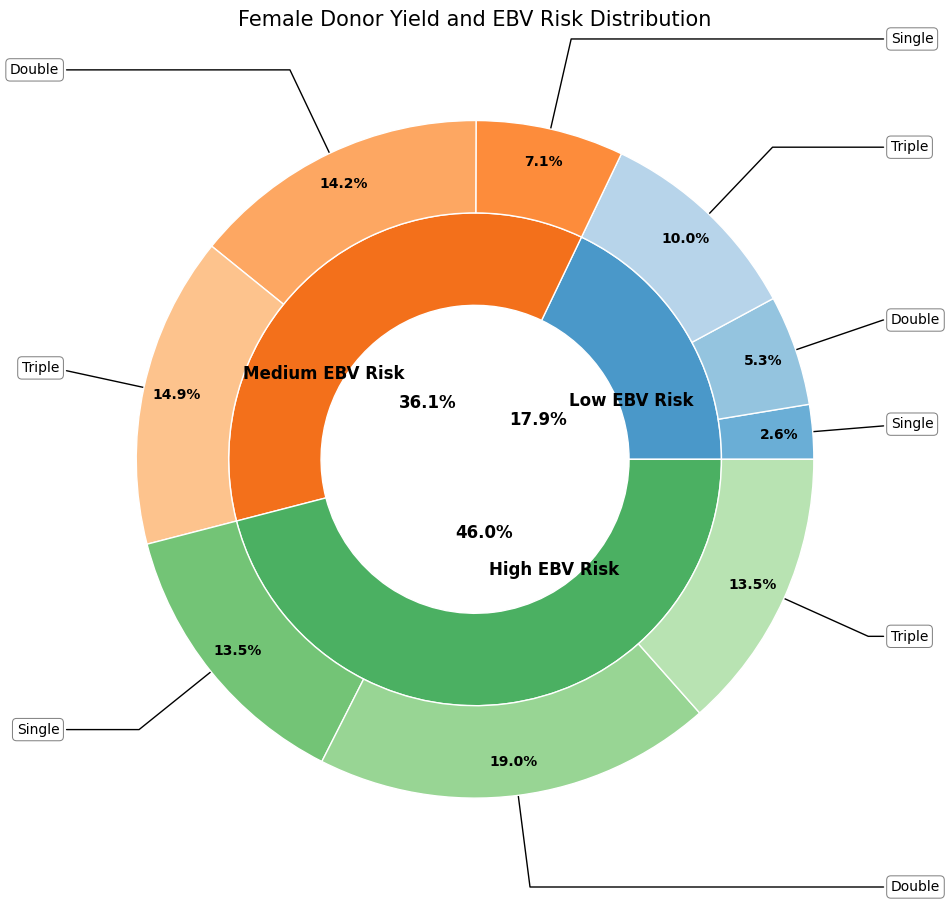

In [ ]:
# Data setup
outer_vals = [lr_single_female, lr_double_female, lr_triple_female, 
                mr_single_female, mr_double_female, mr_triple_female, 
                hr_single_female, hr_double_female, hr_triple_female]
inner_vals = [low_risk_EBV_bracket_female, medium_risk_EBV_bracket_female, high_risk_EBV_bracket_female]

labels_outer = ['Single', 'Double', 'Triple', 'Single', 'Double', 'Triple', 'Single', 'Double', 'Triple']
labels_inner = ['Low EBV Risk', 'Medium EBV Risk', 'High EBV Risk']

fig, ax = plt.subplots(figsize=(10, 10))

# Using specific colormaps for uniformity within categories
cmap_low = plt.cm.Blues
cmap_med = plt.cm.Oranges
cmap_high = plt.cm.Greens

colors_inner = [cmap_low(0.6), cmap_med(0.6), cmap_high(0.6)]
colors_outer = [
    cmap_low(0.5), cmap_low(0.4), cmap_low(0.3),  # Blues for Low Risk
    cmap_med(0.5), cmap_med(0.4), cmap_med(0.3),  # Oranges for Medium Risk
    cmap_high(0.5), cmap_high(0.4), cmap_high(0.3) # Greens for High Risk
]

# --- OUTER PIE (Risk Levels) ---
ax.pie(inner_vals, radius=.8, colors=colors_inner,
       labels=labels_inner, labeldistance=0.45,
       textprops={'fontsize': 12, 'weight': 'bold', 'color': 'black'},
       wedgeprops=dict(width=0.3, edgecolor='w'), autopct='%1.1f%%',
       pctdistance=.3)

# --- INNER PIE (Single/Double/Triple) ---
wedges, _, _ = ax.pie(outer_vals, radius=1.1, colors=colors_outer,
                   wedgeprops=dict(width=0.3, edgecolor='w'), startangle=0,
                   autopct='%1.1f%%', pctdistance=.9,
                   textprops={'fontsize': 10, 'weight': 'bold', 'color': 'black'})

# --- ANNOTATIONS (The "Single/Double/Triple" labels) ---
bbox_props = dict(boxstyle="round,pad=0.3", fc="w", ec='0.5', lw=0.72)
kw = dict(arrowprops=dict(arrowstyle="-"),
          bbox=bbox_props, zorder=0, va="center")

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    ax.annotate(labels_outer[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                horizontalalignment=horizontalalignment, fontsize=10,**kw)

ax.set(aspect="equal")
plt.title('Female Donor Yield and EBV Risk Distribution', pad=35, fontsize=15)
plt.show()

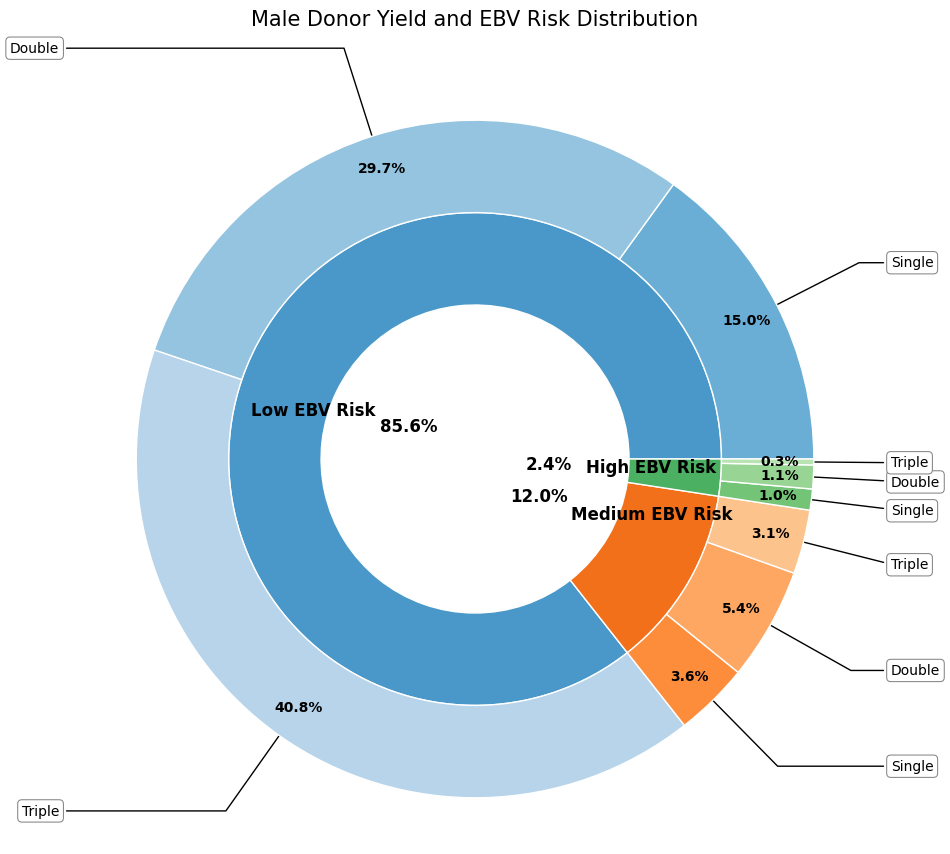

In [ ]:
# Data setup
outer_vals = [lr_single_male, lr_double_male, lr_triple_male, 
                mr_single_male, mr_double_male, mr_triple_male, 
                hr_single_male, hr_double_male, hr_triple_male]
inner_vals = [low_risk_EBV_bracket_male, medium_risk_EBV_bracket_male, high_risk_EBV_bracket_male]

labels_outer = ['Single', 'Double', 'Triple', 'Single', 'Double', 'Triple', 'Single', 'Double', 'Triple']
labels_inner = ['Low EBV Risk', 'Medium EBV Risk', 'High EBV Risk']

fig, ax = plt.subplots(figsize=(10, 10))

# Using specific colormaps for uniformity within categories
cmap_low = plt.cm.Blues
cmap_med = plt.cm.Oranges
cmap_high = plt.cm.Greens

colors_inner = [cmap_low(0.6), cmap_med(0.6), cmap_high(0.6)]
colors_outer = [
    cmap_low(0.5), cmap_low(0.4), cmap_low(0.3),  # Blues for Low Risk
    cmap_med(0.5), cmap_med(0.4), cmap_med(0.3),  # Oranges for Medium Risk
    cmap_high(0.5), cmap_high(0.4), cmap_high(0.3) # Greens for High Risk
]

# --- OUTER PIE (Risk Levels) ---
ax.pie(inner_vals, radius=.8, colors=colors_inner,
       labels=labels_inner, labeldistance=0.45,
       textprops={'fontsize': 12, 'weight': 'bold', 'color': 'black'},
       wedgeprops=dict(width=0.3, edgecolor='w'), autopct='%1.1f%%',
       pctdistance=.3)

# --- INNER PIE (Single/Double/Triple) ---
wedges, _, _ = ax.pie(outer_vals, radius=1.1, colors=colors_outer,
                   wedgeprops=dict(width=0.3, edgecolor='w'), startangle=0,
                   autopct='%1.1f%%', pctdistance=.9,
                   textprops={'fontsize': 10, 'weight': 'bold', 'color': 'black'})

# --- ANNOTATIONS (The "Single/Double/Triple" labels) ---
bbox_props = dict(boxstyle="round,pad=0.3", fc="w", ec='0.5', lw=0.72)
kw = dict(arrowprops=dict(arrowstyle="-"),
          bbox=bbox_props, zorder=0, va="center")

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    ax.annotate(labels_outer[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                horizontalalignment=horizontalalignment, fontsize=10,**kw)

ax.set(aspect="equal")
plt.title('Male Donor Yield and EBV Risk Distribution', pad=35, fontsize=15)
plt.show()

## Training the model

### Training function

In [ ]:
# Model training function after grid search, with GPU acceleration using XGBoost's native GPU support.
def train_label_predictor(history_df: pd.DataFrame, 
                          max_samples: int =5000000):
    # Sort by donorID and donationElapsedTime to maintain temporal order for each donor
    history_df = history_df.sort_values(['donorID', 'donationElapsedTime'])

    # Sampling after lag computation to preserve temporal context
    if len(history_df) > max_samples:
        train_data = history_df.sample(n=max_samples, random_state=42).copy()
    else:
        train_data = history_df.copy()

    # Feature Selection
    features = [
        'donorAge', 'reactionSeverity',
        'donorCurrentDonationReaction', 'timePressureBarGoingToYellowInSeconds',
        'instancesMachineWasStoppedByOperator', 'instancesMachineStopped',
        'lowerPlateletsCount', 'donationElapsedTime', 'donorSex',
        'needleAdjusted', 'donorHasLowDrawHistory', 'donorHasHighReturnHistory',
        'donorEBVRiskBracket', 'prev_variance', 'prev_variance_1',
        'machineRedSquaresVarianceInCicles', 'donationTime',
        'donorHasACReactionHistory', 'prevACReaction', 'yield', 'operator', 'veinUsed',
        'highReturnInstances', 'totalDonations'
    ]
    
    # Separate features and target
    X = train_data[features].copy()
    y = train_data['label'].copy()

    # Categorical Encoding
    le_dict = {}
    cat_cols = X.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le
        
    target_le = LabelEncoder()
    y_encoded = target_le.fit_transform(y)
    num_classes = len(target_le.classes_)
    
    # Downcast to float32 for GPU memory efficiency
    X = X.astype('float32')
    
    # 60% train, 20% validation, 20% test split with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=37, stratify=y_train
    )

    # XGBoost Native GPU Configuration
    print("Initializing GPU training...")
    
    # Pass NumPy arrays to the GPU constructor
    dtrain = xgb.QuantileDMatrix(X_train.values, label=y_train, feature_names=X_train.columns.tolist())
    dval = xgb.DMatrix(X_val.values, label=y_val, feature_names=X_val.columns.tolist())   
    dtest = xgb.DMatrix(X_test.values, label=y_test, feature_names=X_test.columns.tolist())

    # Best found parameters: {'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100}

    params = {
        'tree_method': 'hist',
        'device': 'cuda',
        'objective': 'multi:softprob',
        'num_class': num_classes,
        'max_depth': 8,   
        'gamma': 0.1,            
        'eta': 0.1,                 
        'random_state': 42,
        'objective': 'multi:softprob'
    }

    # Train with early stopping
    evals = [(dtrain, 'train'), (dval, 'val')]
    bst = xgb.train(
        params, 
        dtrain, 
        num_boost_round=100, 
        evals=evals,
        early_stopping_rounds=5,
        verbose_eval=100
    )

    # Boosting rounds
    rounds = bst.best_iteration if hasattr(bst, 'best_iteration') else bst.num_boosted_rounds()

    # Total trees
    total_trees = rounds * len(target_le.classes_)
    print(f"Total trees in model: {total_trees}")

    # Evaluation
    probs = bst.predict(dtest)
    y_pred = np.argmax(probs, axis=1)
    
    print("\nModel Evaluation (Updated Version):")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_le.classes_))

    return bst, target_le, le_dict, X_test, y_test


In [ ]:
# Using a more sophisticated hyperparameter tuning approach with Grid Search 
# to find the best parameters for the XGBoost model using the synthetic noisy dataset.
def train_label_predictor_with_grid_search(history_df: pd.DataFrame, max_samples: int = 1000000):
    if len(history_df) > max_samples:
        train_data = history_df.sample(n=max_samples, random_state=42).copy()
    else:
        train_data = history_df.copy()

    features = [
        'donorAge', 'reactionSeverity',
        'donorCurrentDonationReaction', 'timePressureBarGoingToYellowInSeconds',
        'instancesMachineWasStoppedByOperator', 'instancesMachineStopped',
        'lowerPlateletsCount', 'donationElapsedTime', 'donorSex',
        'needleAdjusted', 'donorHasLowDrawHistory', 'donorHasHighReturnHistory',
        'donorEBVRiskBracket', 'prev_variance', 'prev_variance_1',
        'machineRedSquaresVarianceInCicles', 'donationTime',
        'donorHasACReactionHistory', 'prevACReaction', 'yield', 'operator', 'veinUsed',
        'highReturnInstances', 'totalDonations'
    ]
    
    X = train_data[features].copy()
    y = train_data['label'].copy()

    le_dict = {}
    cat_cols = X.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le
        
    target_le = LabelEncoder()
    y_encoded = target_le.fit_transform(y)
    num_classes = len(target_le.classes_)
    
    X = X.astype('float32')
    
    # 80% train, 20% test split with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print("Initializing Grid Search on GPU...")
    
    xgb_model = xgb.XGBClassifier(
        tree_method='hist',
        device='cuda',
        objective='multi:softprob',
        num_class=num_classes,
        random_state=42,
        eval_metric='mlogloss'
    )

    param_grid = {
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 300],
        'gamma': [0, 0.1, 0.2]
    }

    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='f1_macro', # Using f1_macro instead of accuracy for imbalanced data
        cv=3,
        verbose=2,
        n_jobs=1 
    )

    # Pass sample_weight to the fit method
    # grid_search.fit(X_train, y_train, sample_weight=sample_weights)
    grid_search.fit(X_train, y_train)

    print("\nBest Parameters Found:")
    print(grid_search.best_params_)
    
    best_model = grid_search.best_estimator_

    # Final Evaluation
    y_pred = best_model.predict(X_test)
    
    print("\nModel Evaluation (Optimized via Grid Search with Class Weights):")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_le.classes_))

    return best_model, target_le, le_dict, X_test, y_test


### Noisy dataset model

In [17]:
grid_model, grid_target_encoder, grid_feature_encoders, X_test_grid, y_test_grid = train_label_predictor_with_grid_search(noisy_dataset)

Initializing Grid Search on GPU...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, n_estimators=100; total time=   2.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, n_estimators=100; total time=   2.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, n_estimators=100; total time=   2.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, n_estimators=300; total time=   5.8s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, n_estimators=300; total time=   5.8s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, n_estimators=300; total time=   5.8s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, n_estimators=100; total time=   2.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, n_estimators=100; total time=   2.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, n_estimators=100; total time=   2.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, n_estimators=300; total time=   6.9s
[CV] END gamma=0, learn

In [20]:
n_model, n_target_encoder, n_feature_encoders, X_test_n, y_test_n = train_label_predictor(noisy_dataset)

Initializing GPU training...
[0]	train-mlogloss:1.26688	val-mlogloss:1.26696
[91]	train-mlogloss:0.04135	val-mlogloss:0.04650
Total trees in model: 602

Model Evaluation (Updated Version):
Accuracy: 0.9905

Classification Report:
                                             precision    recall  f1-score   support

  End donation, AC toxicity reached/buildup       1.00      0.98      0.99     13457
    Inform nurse and lower AC concentration       0.99      0.97      0.98     12858
           Lower return speed from terminal       0.94      0.94      0.94     22214
                                  No action       0.99      1.00      0.99    371726
Pause machine for 1 minute and inform nurse       1.00      0.98      0.99     15284
            Request first needle adjustment       0.99      0.97      0.98     15938
           Request second needle adjustment       0.99      0.96      0.98     10663

                                   accuracy                           0.99    462140
   

### Noiseless dataset model

In [19]:
model, target_encoder, feature_encoders, X_test, y_test = train_label_predictor(dataset)

Initializing GPU training...
[0]	train-mlogloss:1.25747	val-mlogloss:1.25746
[99]	train-mlogloss:0.00008	val-mlogloss:0.00009
Total trees in model: 693

Model Evaluation (Updated Version):
Accuracy: 1.0000

Classification Report:
                                             precision    recall  f1-score   support

  End donation, AC toxicity reached/buildup       1.00      1.00      1.00     13193
    Inform nurse and lower AC concentration       1.00      1.00      1.00     12597
           Lower return speed from terminal       1.00      1.00      1.00     21996
                                  No action       1.00      1.00      1.00    373265
Pause machine for 1 minute and inform nurse       1.00      1.00      1.00     15033
            Request first needle adjustment       1.00      1.00      1.00     15681
           Request second needle adjustment       1.00      1.00      1.00     10375

                                   accuracy                           1.00    462140
   

## Models results

In [45]:
# Function to plot the confusion matrix for the donor action predictor model, 
# with enhanced aesthetics and a logarithmic color scale for better visibility of class imbalances.
def plot_donor_confusion_matrix(y_true: np.ndarray, 
                                y_pred: np.ndarray, 
                                class_names: np.ndarray):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(16, 14))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(
        cmap='YlGnBu', 
        ax=ax, 
        xticks_rotation='vertical', 
        values_format=',d',
        im_kw={'norm': LogNorm(vmin=1)}
    )
    
    # Aesthetic enhancements
    plt.title('Confusion Matrix: Donor Action Predictor', fontsize=22, pad=25, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=16, labelpad=15)
    plt.ylabel('True Label', fontsize=16, labelpad=15)
    
    # Improve font sizes on the axis tick labels
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Adjust font size of the numbers inside the matrix cells
    for text in disp.text_.ravel():
        text.set_fontsize(11)
    
    plt.tight_layout()
    plt.show()


# Function to predict labels on the test set using the trained model,
# ensuring that the feature names are preserved for compatibility with XGBoost's DMatrix.
def predict_labels(model: xgb.core.Booster, 
                   original_test_data: pd.DataFrame, 
                   encoder: LabelEncoder, 
                   mode: str = 'standard'):
    # Ensure we are working on a copy
    test_data = original_test_data.copy()
    
    # Standardize types while keeping it as a DataFrame to preserve feature names
    for col in test_data.columns:
        if test_data[col].dtype == 'int64':
            test_data[col] = test_data[col].astype('int32')
        elif test_data[col].dtype == 'float64':
            test_data[col] = test_data[col].astype('float32')

    print("Predicting...")
    
    if mode == 'standard':
        # If 'model' is a raw xgb.Booster, it needs a DMatrix with feature names
        # If 'model' is an XGBClassifier, it can take the DataFrame directly
        try:
            # Try predicting directly first
            preds = model.predict(test_data)
        except TypeError:
            # Fallback for raw Booster: Create DMatrix WITH feature names
            dtest = xgb.DMatrix(test_data, feature_names=test_data.columns.tolist())
            probs = model.predict(dtest)
            preds = np.argmax(probs, axis=1)
            
    elif mode == 'grid':
        # Grid search models are always sklearn-compatible
        preds = model.predict(test_data)

    # Map back to labels
    print("Mapping predictions back to history dataframe...")
    test_data['predicted_label'] = encoder.inverse_transform(preds)
    
    return test_data

### Noiseless

Predicting...
Mapping predictions back to history dataframe...


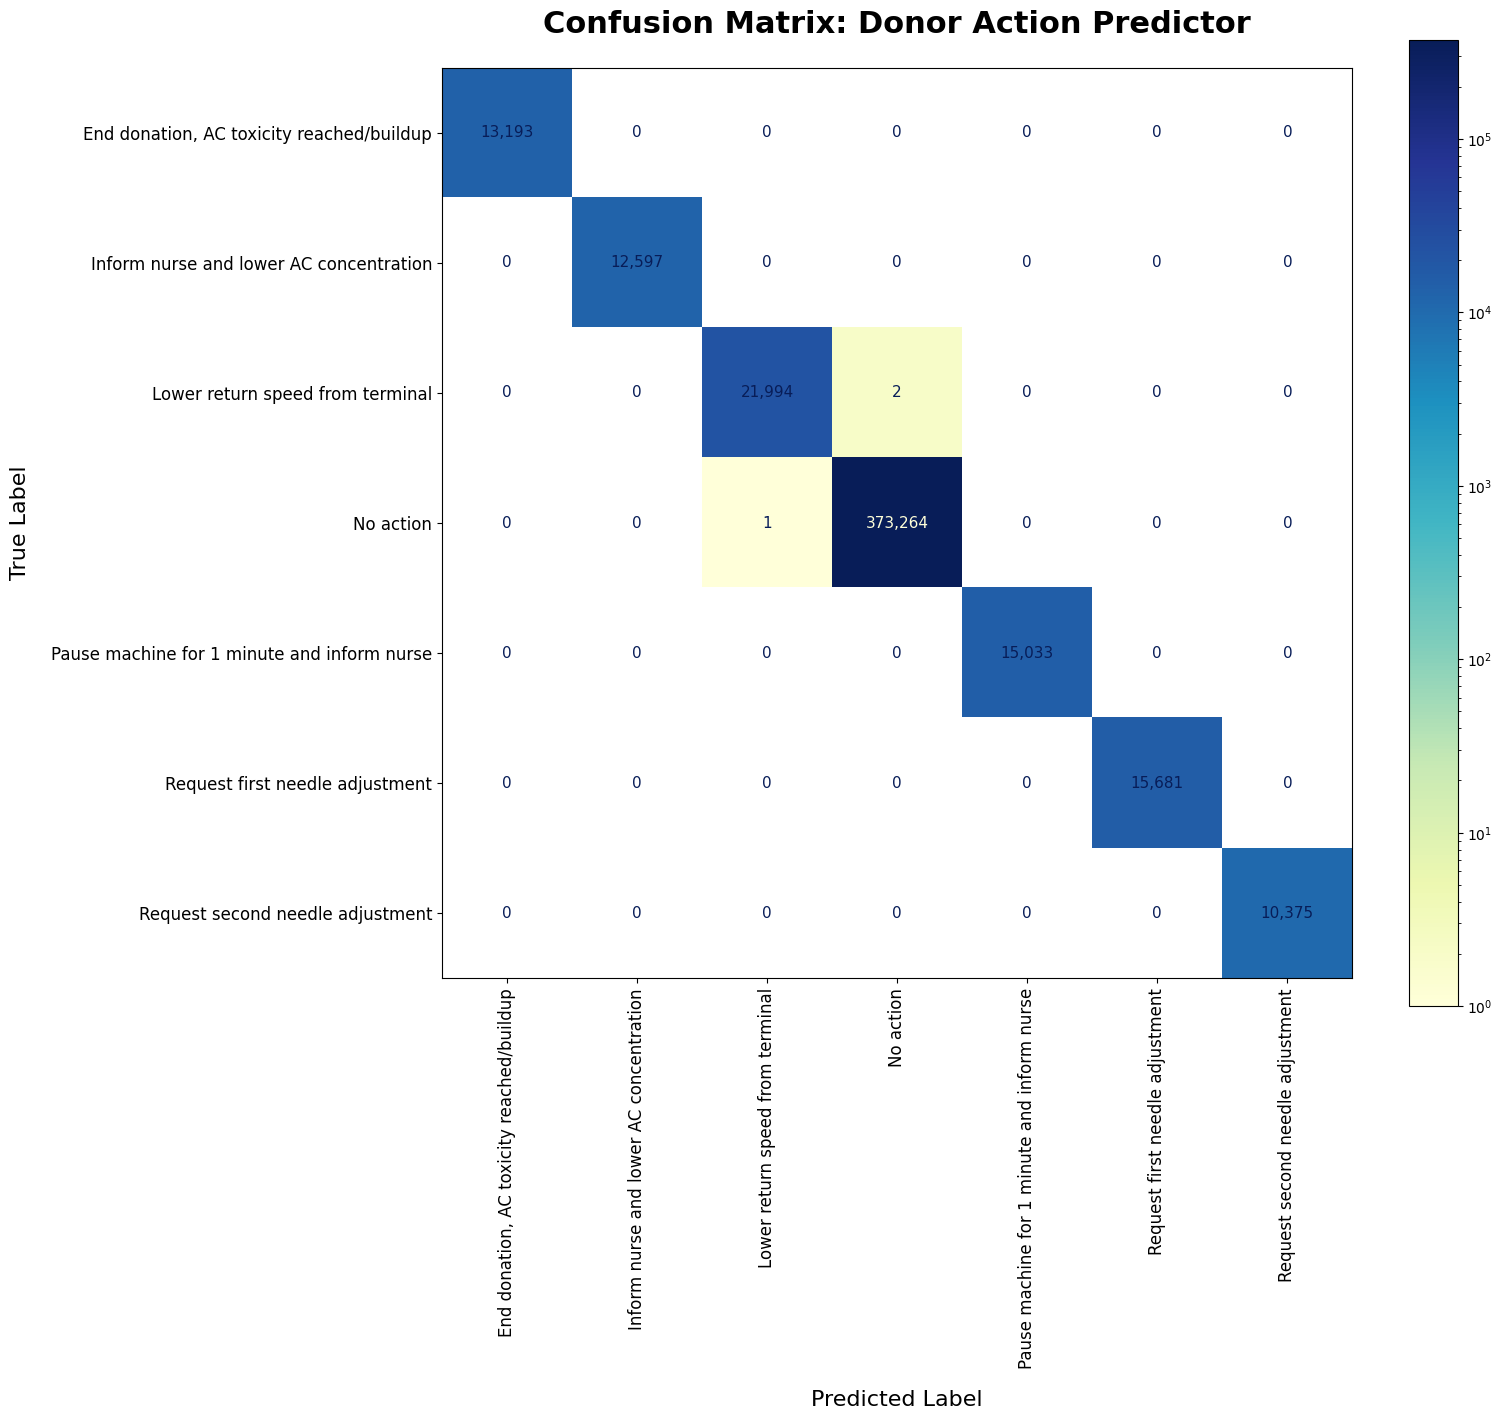

In [46]:
pred_X_test = predict_labels(model, X_test, target_encoder)
y_true_encoded = target_encoder.transform(pred_X_test['predicted_label'].astype(str))
plot_donor_confusion_matrix(y_test, y_true_encoded, target_encoder.classes_)

### Noisy

Predicting...
Mapping predictions back to history dataframe...


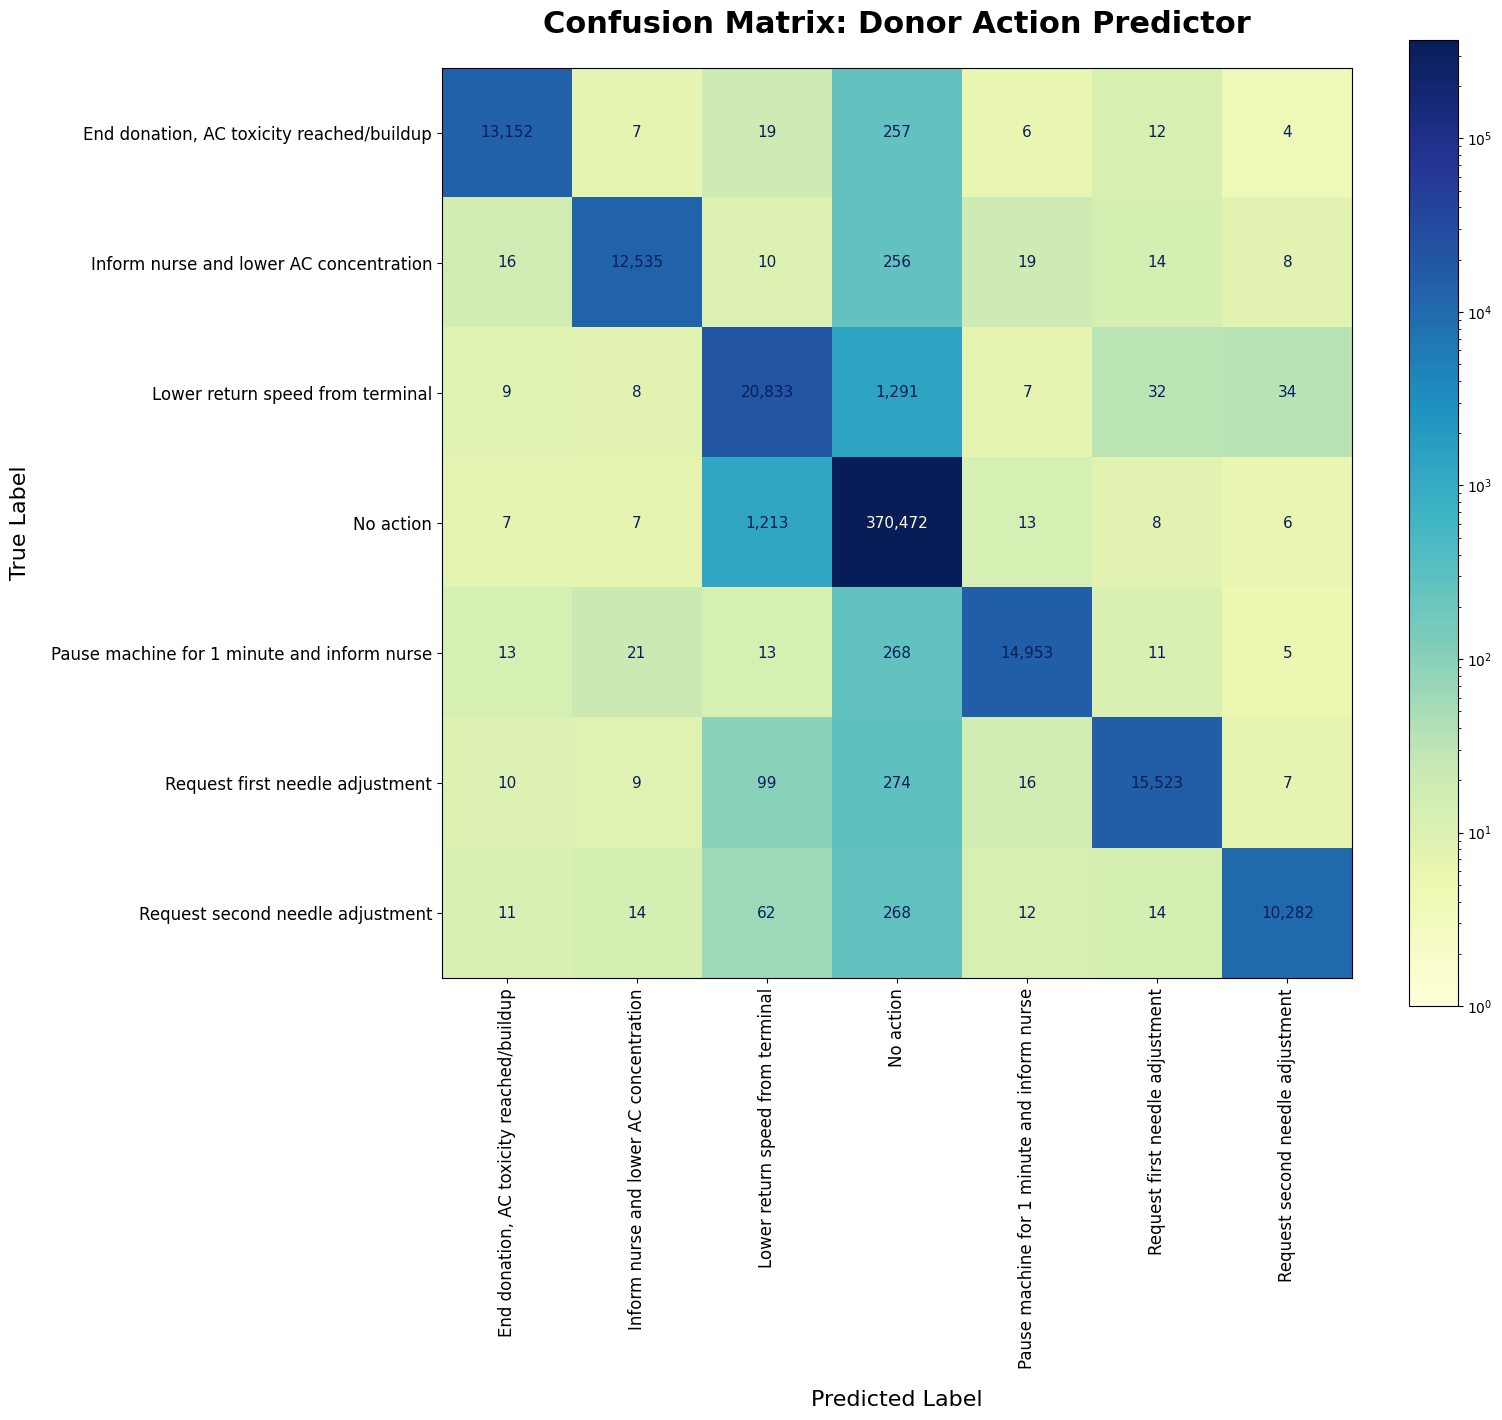

In [47]:
pred_X_test = predict_labels(n_model, X_test_n, n_target_encoder)
y_true_encoded = n_target_encoder.transform(pred_X_test['predicted_label'].astype(str))
plot_donor_confusion_matrix(y_test_n, y_true_encoded, n_target_encoder.classes_)

## Saving the model

In [ ]:
# Wrapper class to encapsulate the entire inference pipeline, including feature encoding and prediction, for deployment
class XGBInferenceWrapper:
    def __init__(self, model, le_dict, target_encoder):
        self.model = model
        self.le_dict = le_dict 
        self.target_encoder = target_encoder
        self.feature_names = [
            'donorAge', 'reactionSeverity', 'donorCurrentDonationReaction', 
            'timePressureBarGoingToYellowInSeconds', 'instancesMachineWasStoppedByOperator', 
            'instancesMachineStopped', 'lowerPlateletsCount', 'donationElapsedTime', 
            'donorSex', 'needleAdjusted', 'donorHasLowDrawHistory', 
            'donorHasHighReturnHistory', 'donorEBVRiskBracket', 'prev_variance', 
            'prev_variance_1', 'machineRedSquaresVarianceInCicles', 'donationTime', 
            'donorHasACReactionHistory', 'prevACReaction', 'yield', 'operator', 
            'veinUsed', 'highReturnInstances', 'totalDonations'
        ]

    def predict(self, params_dict):
        # Convert to DataFrame and LOCK the column order
        df = pd.DataFrame([params_dict])
        
        # Ensure only training features are present and in the right order
        df = df[self.feature_names].copy()

        # Encode categorical columns
        for col, encoder in self.le_dict.items():
            if col in df.columns:
                # Force to string to match '.astype(str)' used in training
                val_as_str = str(df.iloc[0][col]) 
                try:
                    df[col] = encoder.transform([val_as_str])[0]
                except ValueError:
                    # Fallback for unseen labels: use the first known class
                    df[col] = 0 

        # Final Type Cast
        df = df.astype('float32')

        # XGBoost Prediction
        dmat = xgb.DMatrix(df, feature_names=self.feature_names)
        probs = self.model.predict(dmat)

        # Handle Softprob Output
        class_index = np.argmax(probs, axis=1)
        
        return self.target_encoder.inverse_transform(class_index)

# Saving the inference pipeline as a pickle file for deployment
wrapper = XGBInferenceWrapper(model, feature_encoders, target_encoder)
joblib.dump(wrapper, 'inference_pipeline_mk3.pkl')